In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df=pd.read_csv('Advertising.csv')

In [3]:
df.head()


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
# Checking dataset dimensions

print("Dataset shape:", df.shape)

# Checking column names
print("\nColumns:")
print(df.columns)

# Checking data types and non-null values
print("\nDataset information:")
df.info()

Dataset shape: (200, 4)

Columns:
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


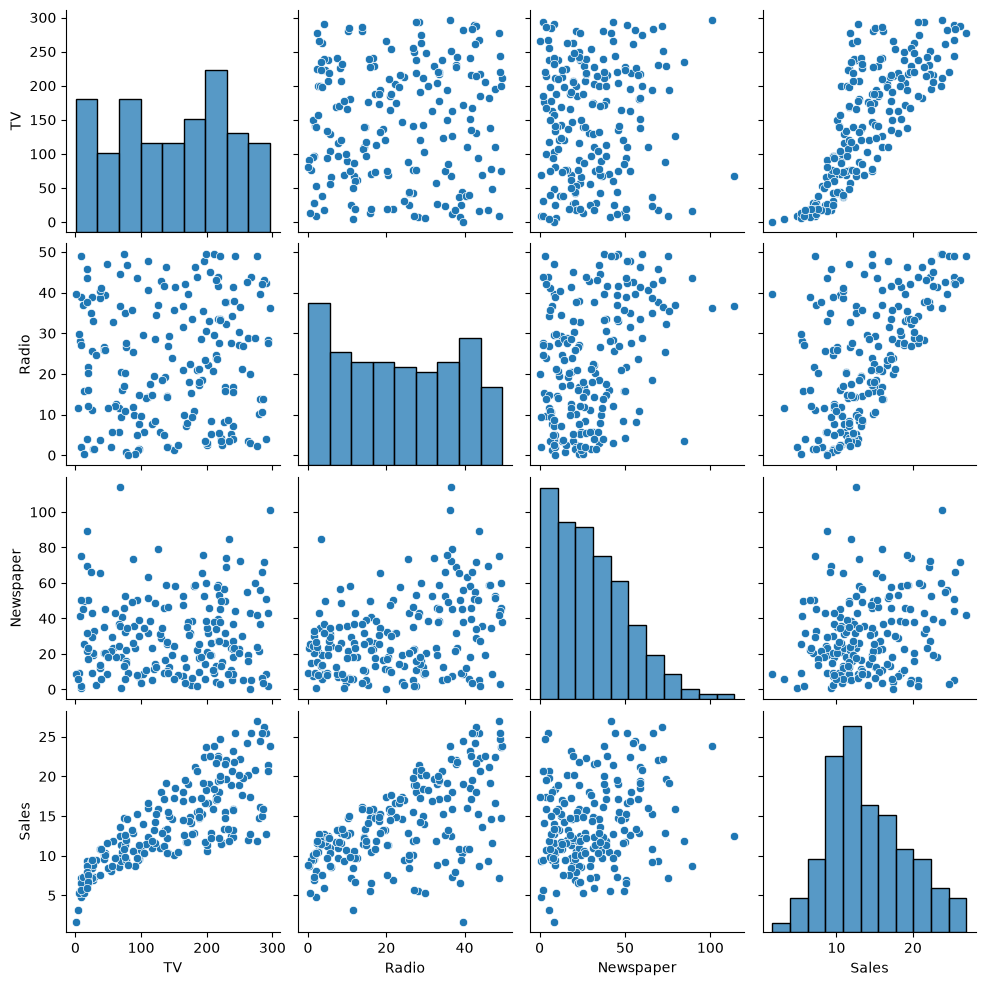

In [10]:
# Pairplot to visualize relationships between all variables
sns.pairplot(df)
plt.show()

### INDIVIDUAL PLOTS:

### 1.SALES Vs TV:

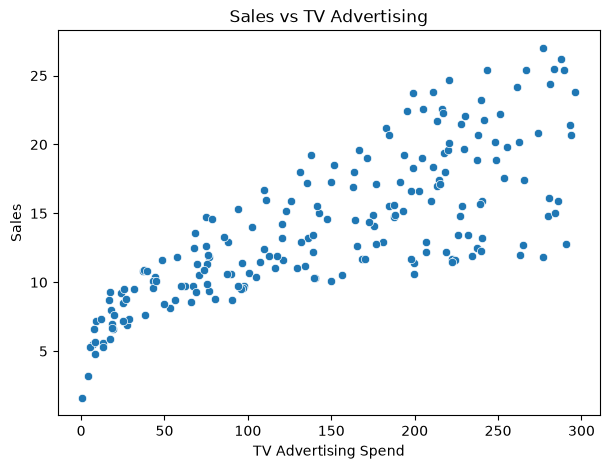

In [11]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

TV and Sales* show a strong positive correlation of *0.78*, indicating that higher TV advertising is associated with higher sales.

### 2.SALES Vs RADIO:

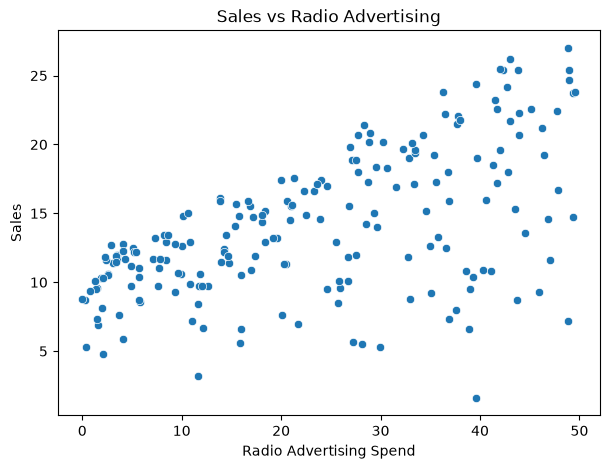

In [12]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

Radio and Sales* have a moderate positive correlation of *0.58*, showing a noticeable relationship

### 3.SALES Vs NEWSPAPER:

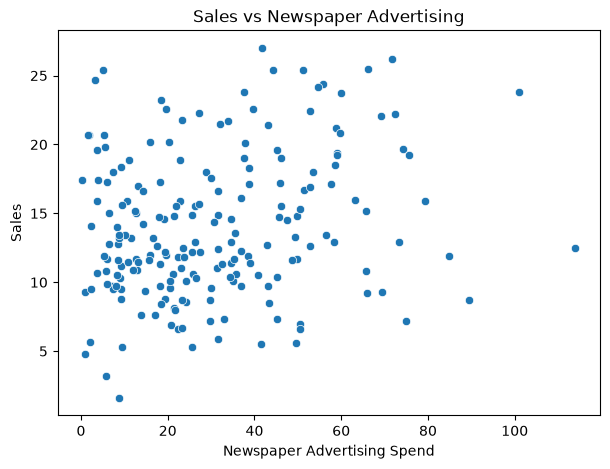

In [13]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

Newspaper and Sales* have a weak positive correlation of *0.23*, indicating a relatively low relationship.

In [14]:
# Calculate correlation matrix

correlation = df.corr()

correlation

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


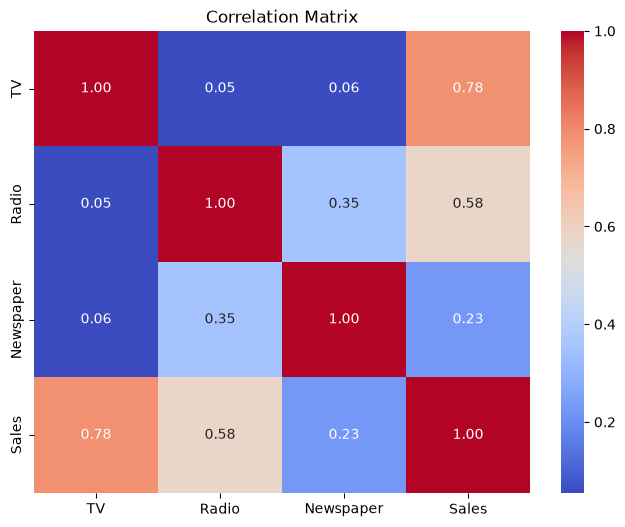

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

TV and Sales have a strongest positive correlation of 0.78,showing that advertising is closely related to higher sales.
Radio and Sales have a moderate positive correlation of 0.58, including a noticeable relationship.
Nwepaper and Sales have a weak positive correlation of 0.23, so its impact appears relatively low.
Overall, TV advertising has the strongest relationship with sales, followed by Radio and Newspaper.

### DEFINING FEATURES AND TARGET:

In [17]:
# Features
X = df[["TV", "Radio", "Newspaper"]]

# Target
y = df["Sales"]

### TRAIN_YEST_SPLIT:

In [18]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


### LINEAR REGRESSION BASELINE MODEL:

In [19]:
# Create Linear Regression model

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
linear_predictions = linear_model.predict(X_test)

In [20]:
# CalculatING evaluation metrics

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

Linear Regression Results
-------------------------
MAE : 1.461
RMSE: 1.782
R²  : 0.899


### RANDOM FOREST REGRESSOR:

In [21]:
# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

In [22]:
# Calculate evaluation metrics

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest Results
---------------------
MAE : 0.629
RMSE: 0.758
R²  : 0.982


### COMPARING BOTH THE MODELS:

In [23]:


results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628925,0.757657,0.981813


### Model Performance Comparison

The performance of **Linear Regression** and **Random Forest Regressor** was evaluated using **MAE, RMSE, and R² Score**. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates that the model explains more variance in sales.

Based on the results, **Random Forest Regressor performs better than Linear Regression**, with a lower MAE of **0.6289**, lower RMSE of **0.7577**, and higher R² Score of **0.9818**. Therefore, **Random Forest Regressor is selected as the best model** for predicting product sales in this project.


In [24]:
# Select the model with the lowest RMSE

best_model_name = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Random Forest


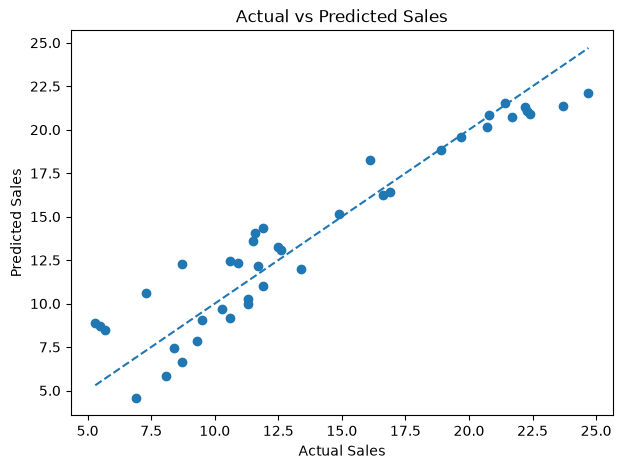

In [25]:
# Actual vs predicted sales

plt.figure(figsize=(7, 5))

plt.scatter(y_test, linear_predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

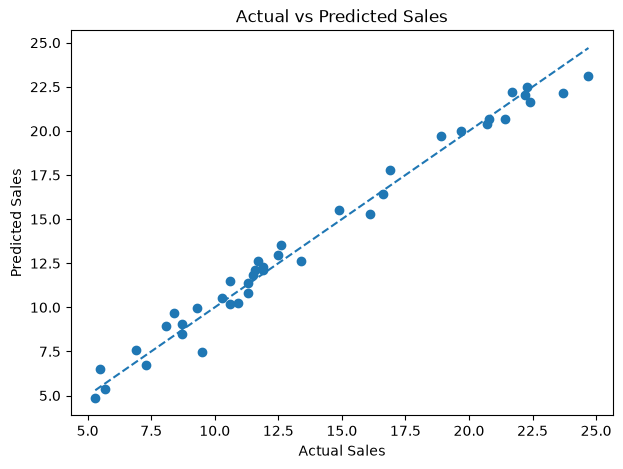

In [26]:
# Actual vs predicted sales

plt.figure(figsize=(7, 5))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

### Actual vs Predicted Sales — Linear Regression vs Random Forest

Both models track the diagonal reasonably well, but Linear Regression shows more scatter, especially in the low-to-mid Sales range (5–15), with a few notable outliers (e.g., actual≈16 predicted≈18.3). Random Forest predictions hug the diagonal more tightly across almost the full range, with tighter clustering at higher Sales values (15+). This visually confirms Random Forest's lower MAE/RMSE and higher R² — it captures the mild non-linear (diminishing-returns) TV–Sales relationship better than the linear model. Linear Regression's errors are still fairly evenly spread with no strong systematic bias, so it remains a solid, interpretable baseline. The accuracy gain from Random Forest comes at the cost of losing simple coefficient-based interpretation.

### RESIDUAL PLOTS:

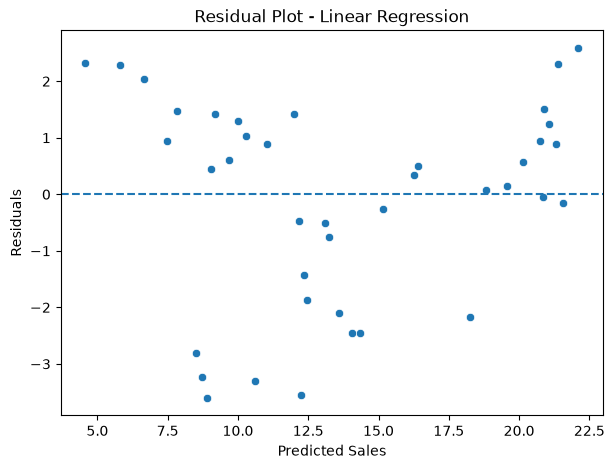

In [27]:
# Calculate residuals

residuals = y_test - linear_predictions

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=linear_predictions,
    y=residuals
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

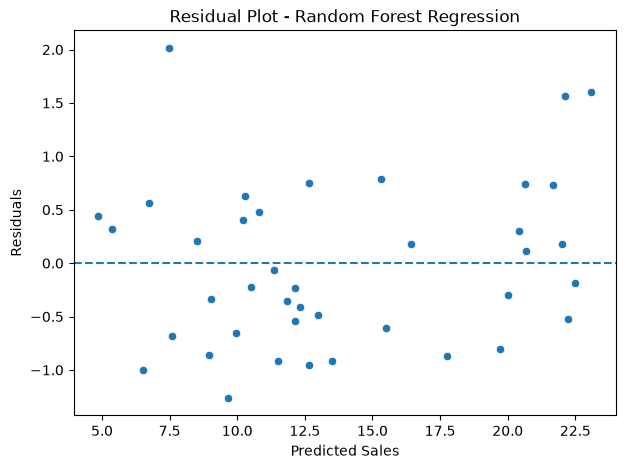

In [28]:
# Calculate residuals

residuals = y_test - rf_predictions

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=rf_predictions,
    y=residuals
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regression")

plt.show()

### Residual Plots — Linear Regression vs Random Forest

Linear Regression residuals show a clear systematic pattern: predictions in the mid-range (Predicted Sales ≈ 8–14) are consistently under-predicted (large negative residuals down to -3.5), while low and high predictions tend to be over-predicted (positive residuals up to +2.5) — this U-shaped/curved pattern signals the model is missing a non-linear relationship in the data. Random Forest residuals, by contrast, are much smaller in magnitude (mostly within ±1.5) and scattered more randomly around zero across the full range, with no obvious curve or trend. This confirms Random Forest better captures the underlying non-linearity (likely TV's diminishing-returns effect) that Linear Regression's straight-line assumption cannot model. Overall, Random Forest is the better-fitting model here — both in accuracy and in residual behavior.

### Advertising Chanel Impact:Linear Regression

### Random Forest:

In [32]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624729
1,Radio,0.362129
2,Newspaper,0.013142


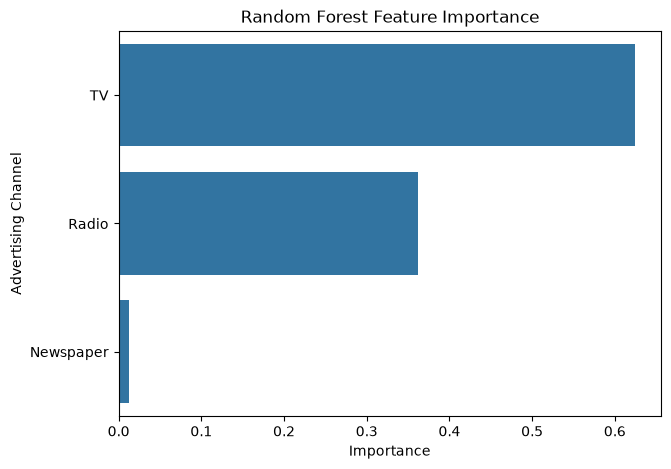

In [33]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

### Random Forest Feature Importance

TV is the dominant driver of Sales, accounting for roughly 62% of the model's total feature importance — by far the largest contributor. Radio follows with a meaningful but secondary role at around 36% importance. Newspaper contributes almost nothing (~1%), confirming it has little predictive power once TV and Radio are accounted for. This ranking matches the Linear Regression coefficients, reinforcing that TV spend should be the top budget priority. Newspaper advertising shows no meaningful relationship with Sales in this dataset and could likely be deprioritized.

## Conclusion

The objective of this project was to predict product sales based on advertising expenditure across TV, Radio, and Newspaper channels.

Linear Regression was trained as the baseline model, followed by Random Forest Regressor as the additional model. Both models were evaluated using MAE, RMSE, and R² score.

The model with the lower RMSE and MAE and higher R² score was selected as the better-performing model.

Feature coefficients/feature importance were analyzed to identify the advertising channel with the greatest impact on sales. The residual plot was also examined to check whether the prediction errors were randomly distributed or showed any systematic pattern.